# 필요한 모듈 임포트

In [125]:
import numpy as np  # ndarray
import pandas as pd  # DataFrame
import matplotlib.pyplot as plt  # 시각화
import seaborn as sns  # 시각화, 예제 데이터셋

# 데이터셋 준비

In [82]:
tips = sns.load_dataset("tips")

In [83]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [84]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# `matplotlib.pyplot` 모듈을 사용한 데이터 시각화

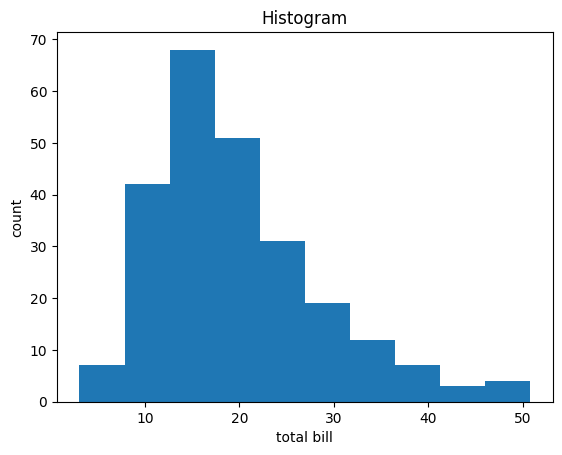

In [85]:
# 1. Figure 객체 생성
fig = plt.figure()

# 2. Figure 객체에 Axes 설정 - Subplot을 생성.
# axis = fig.add_subplot(1, 1, 1)  # add_subplot(nrows, ncols, index)
axis = fig.add_subplot(111)  # add_subplot(pos): "행/열/인덱스" 순서로 만들어진 3자리 정수.
#> add_subplot에서 인덱스는 1부터 시작!

# 3. Axis(축)에 그래프를 그림
axis.hist(x=tips.total_bill)  # 히스토그램

# 4. 그래프 옵션 설정.
axis.set_title("Histogram")
axis.set_xlabel("total bill")
axis.set_ylabel("count")

# 5. 그래프 보여주기.
plt.show()

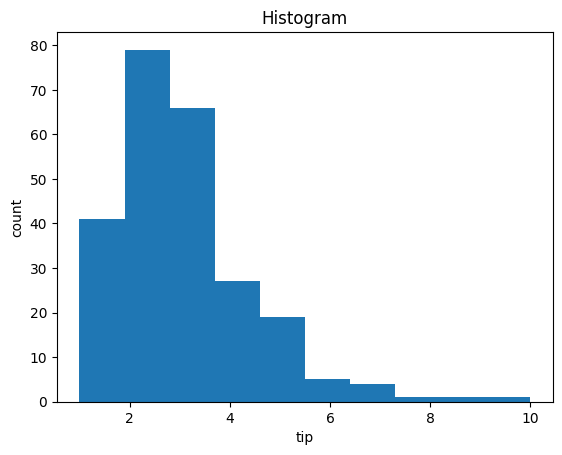

In [86]:
# 1. Figure, Axes 객체 생성
fig, axis = plt.subplots()  # nrows, ncols 파라미터 기본값은 1.

# 2. 그래프 그림.
axis.hist(x=tips.tip)

# 3. 그래프 옵션 설정.
axis.set_title("Histogram")
axis.set_xlabel("tip")
axis.set_ylabel("count")

# 4. 그래프 보여주기.
plt.show()

1개의 Figure에 1개의 Axes(Subplot)만 있는 경우에는 `matplotlib.pyplot` 모듈의 top-level 함수(plot, scatter, hist, ...)를 사용해서 간단히 그래프를 그릴 수 있음.

top-level 함수를 사용할 때는 Figure, Axes 객체를 생성하는 코드를 작성할 필요가 없음.

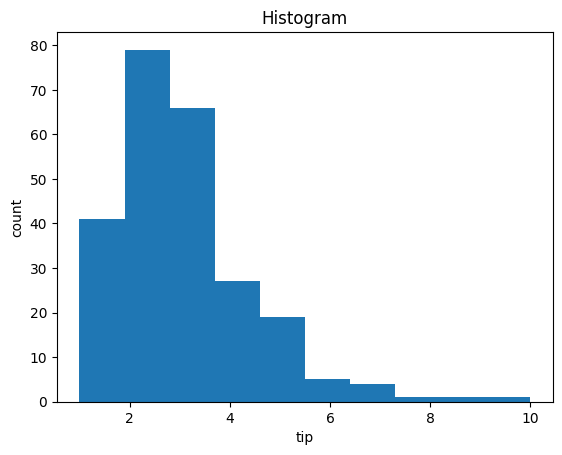

In [87]:
# Figure 객체 생성, Axes 객체 생성, 히스토그램 그리기.
plt.hist(x=tips.tip)

# 그래프 옵션 설정.
plt.title("Histogram")
plt.xlabel("tip")
plt.ylabel("count")

# 그래프 보여주기
plt.show()

# Box Plot(상자 그림)

연속형 자료(숫자 타입 데이터)의 기술 통계량(최솟값, 25%, 중앙값, 75%, 최댓값)과 이상치(outlier)를 상자 모양으로 시각화한 그래프.

In [88]:
tips.total_bill.describe()

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


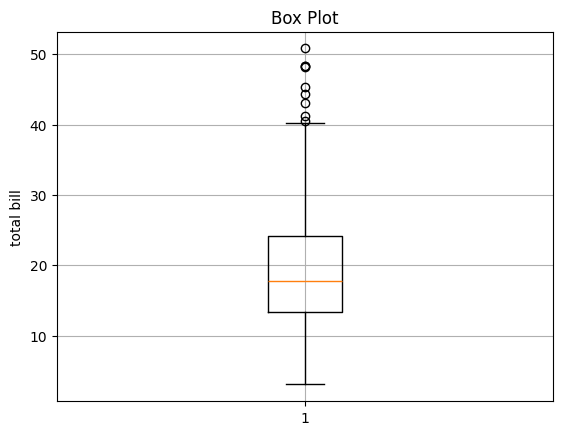

In [89]:
plt.boxplot(x=tips.total_bill)
plt.ylabel('total bill')
plt.title('Box Plot')
plt.grid()
plt.show()

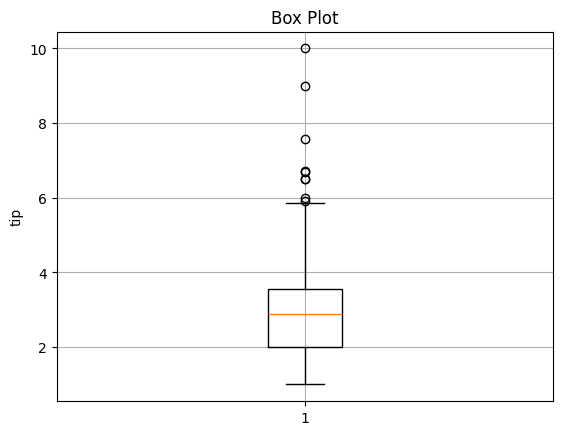

In [90]:
# 팁 box plot
plt.boxplot(x=tips.tip)
plt.ylabel('tip')
plt.title('Box Plot')
plt.grid()
plt.show()

In [91]:
tips.tip.describe()

,tip
count,244.000000
mean,2.998279
std,1.383638
min,1.000000
25%,2.000000
50%,2.900000
75%,3.562500
max,10.000000


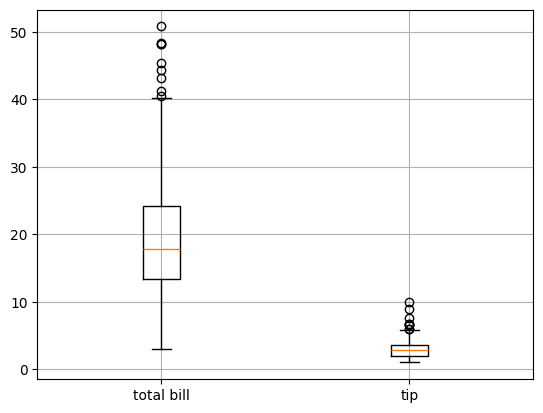

In [92]:
plt.boxplot(x=[tips.total_bill, tips.tip], tick_labels=['total bill', 'tip'])
plt.grid()
plt.show()

1개의 Figure 안에 2개의 Axes(Subplot)을 좌/우로 배치해서, 왼쪽에는 total_bill의 box plot을, 오른쪽에는 tip의 box plot을 시각화.

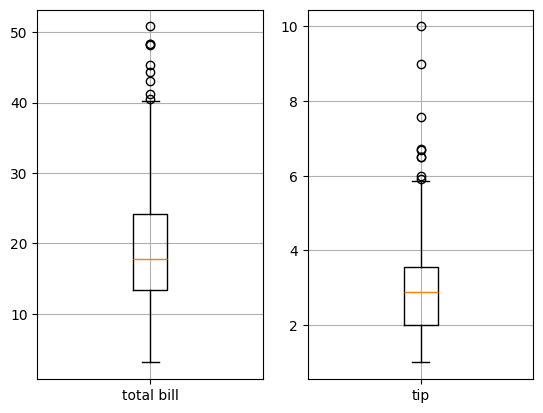

In [93]:
fig = plt.figure()  # Figure 객체 생성

ax1 = fig.add_subplot(1, 2, 1)  # Axes 객체 생성
ax2 = fig.add_subplot(122)  # Axes 객체 생성

ax1.boxplot(x=tips.total_bill, tick_labels=["total bill"])  # 첫번째 Axes에 box plot을 시각화
ax2.boxplot(x=tips.tip, tick_labels=["tip"])  # 두번째 Axes에 box plot을 시각화.

ax1.grid()
ax2.grid()

plt.show()

[<Axes: > <Axes: >]
<class 'numpy.ndarray'>


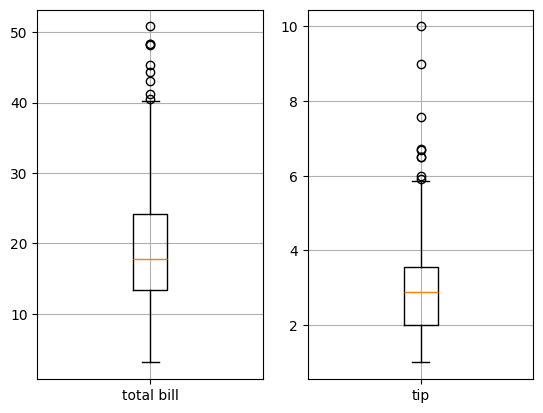

In [94]:
fig, axes = plt.subplots(nrows=1, ncols=2)
print(axes)  # axes: Axes 클래스 객체(들)을 저장하고 있는 배열(ndarray)
print(type(axes))

axes[0].boxplot(x=tips.total_bill, tick_labels=["total bill"])
axes[1].boxplot(x=tips.tip, tick_labels=['tip'])

axes[0].grid()
axes[1].grid()

plt.show()

## 성별 팁의 box plot

*   남성(Male) tip의 기술 통계량 출력
*   여성(Female) tip의 기술 통계량 출력
*   성별 tip의 box plot을 1개의 Axes에 시각화

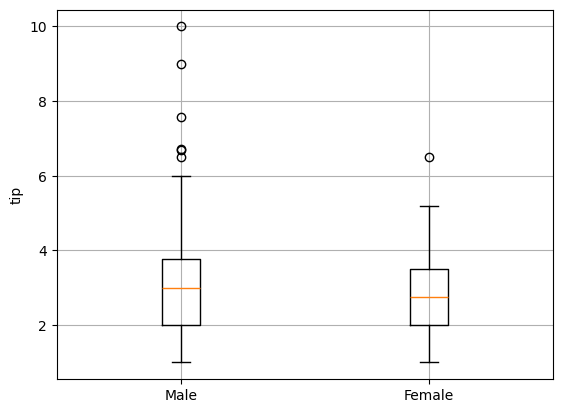

In [95]:
# 강사님 답안

male_tip = tips[tips.sex == "Male"].tip
female_tip = tips[tips.sex == "Female"].tip

male_tip.describe()
female_tip.describe()

plt.boxplot(x=[male_tip, female_tip], tick_labels=["Male", "Female"])
plt.ylabel("tip")
plt.grid()
plt.show()

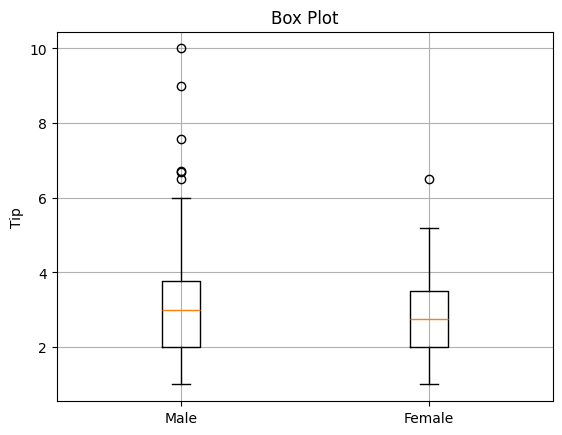

In [96]:
Male_tips = tips[tips.sex == "Male"]
Fem_tips = tips[tips.sex == "Female"]

plt.boxplot(x=[Male_tips.tip, Fem_tips.tip], tick_labels=['Male', 'Female'])
plt.title("Box Plot")
plt.ylabel("Tip")
plt.grid()
plt.show()

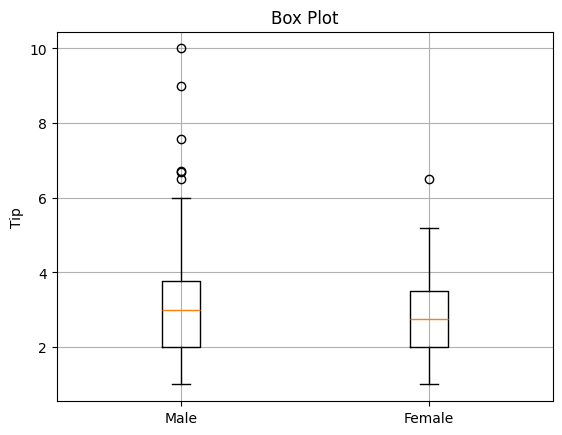

In [97]:
Male_tips = tips[tips.sex == "Male"]
Fem_tips = tips[tips.sex == "Female"]

fig = plt.figure()
ax_gender = fig.add_subplot(111)
ax_gender.boxplot(x=[Male_tips.tip, Fem_tips.tip], tick_labels=["Male", "Female"])
ax_gender.set_title("Box Plot")
ax_gender.set_ylabel("Tip")
ax_gender.grid()
plt.show()

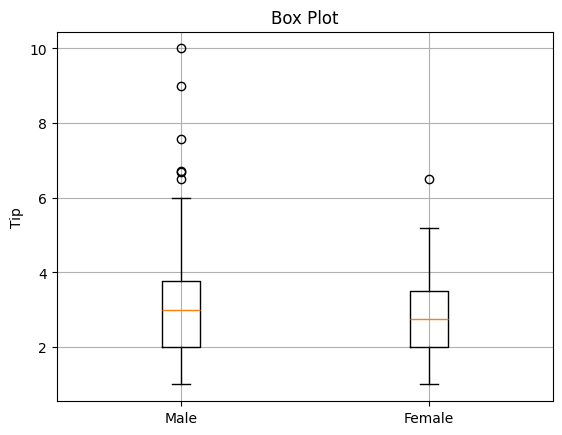

In [98]:
Male_tips = tips[tips.sex == "Male"]
Fem_tips = tips[tips.sex == "Female"]

fig, ax_gender = plt.subplots()
ax_gender.boxplot(x=[Male_tips.tip, Fem_tips.tip], tick_labels=["Male", "Female"])
ax_gender.set_title("Box Plot")
ax_gender.set_ylabel("Tip")
ax_gender.grid()
plt.show()

## 시간(Lunch, Dinner)별 tip의 box plot

In [99]:
# 강사님 답안
tips.time.unique()  # tips 데이터프레임에서 time 컬럼의 유일한(중복되지 않는) 값들.
tips.time.cat.categories  # time 카테고리(범주) 타입 변수의 카테고리(범주)들.

Index(['Lunch', 'Dinner'], dtype='object')

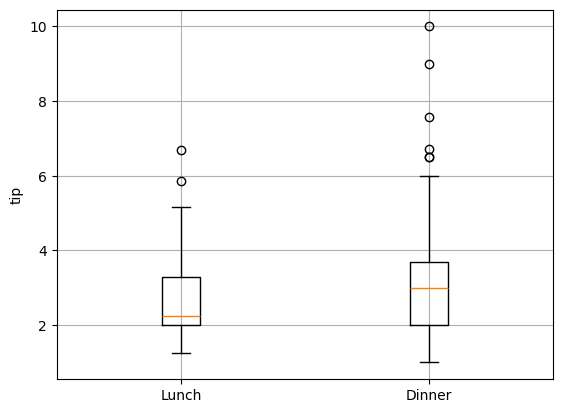

In [100]:
# 강사님 답안
lunch_tip = tips[tips.time == "Lunch"].tip
lunch_tip.describe()

dinner_tip = tips[tips.time == "Dinner"].tip
dinner_tip.describe()

plt.boxplot(x=[lunch_tip, dinner_tip], tick_labels=["Lunch", "Dinner"])
plt.ylabel("tip")
plt.grid()
plt.show()

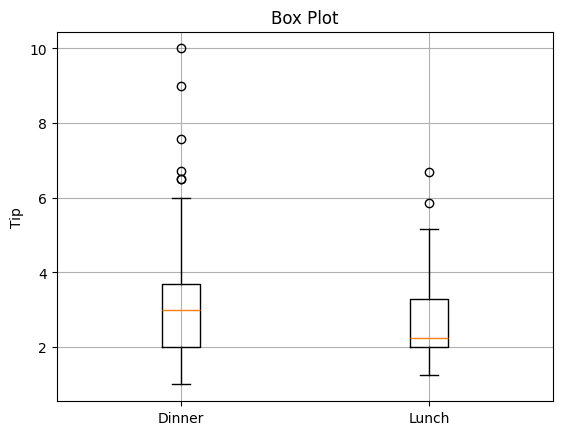

In [101]:
Dinner_tips = tips[tips.time == "Dinner"]
Lunch_tips = tips[tips.time == "Lunch"]

plt.boxplot(x=[Dinner_tips.tip, Lunch_tips.tip], tick_labels=["Dinner", "Lunch"])
plt.ylabel("Tip")
plt.title("Box Plot")
plt.grid()
plt.show()

## 요일(Thur, Fri, Sat, Sun)별 tip의 box plot

In [102]:
# 강사님 답안
tips.day.unique()

for d in tips.day.unique():
    print(d)

Sun
Sat
Thur
Fri


In [103]:
#
tips.day.cat.categories

for d in tips.day.cat.categories:
    print(d)

Thur
Fri
Sat
Sun


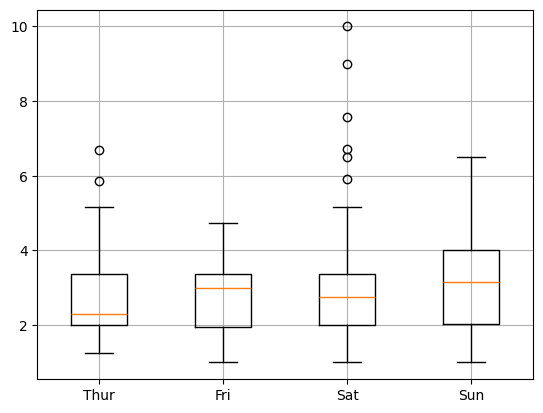

In [104]:
#
thur_tip = tips[tips.day == "Thur"].tip
fri_tip = tips[tips.day == "Fri"].tip
sat_tip = tips[tips.day == "Sat"].tip
sun_tip = tips[tips.day == "Sun"].tip

plt.boxplot(x=[thur_tip, fri_tip, sat_tip, sun_tip],
            tick_labels=tips.day.cat.categories)
plt.grid()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

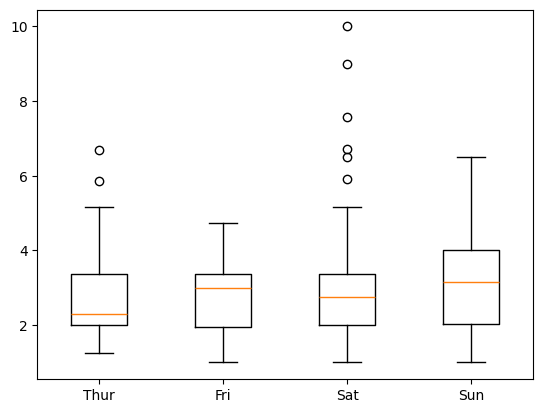

In [105]:
#
day_category = tips.day.cat.categories  # 요일 카테고리(목/금/토/일)
data = []  # 요일별 팁의 컬럼을 저장하기 위한 빈리스트
for d in day_category:
    tip_by_day = tips[tips.day == d].tip
    data.append(tip_by_day)

plt.boxplot(x=data, tick_labels=day_category)
plt.show

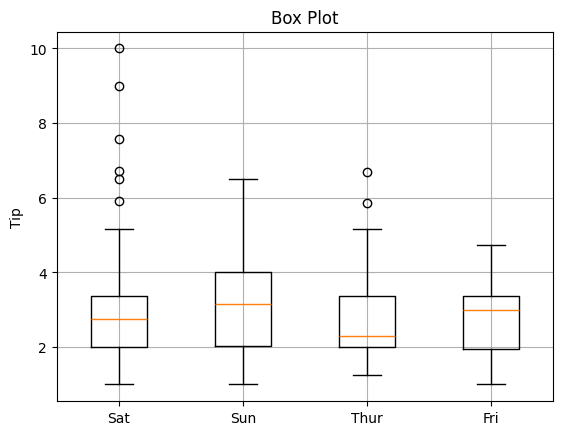

In [106]:
Sat_tips = tips[tips.day == "Sat"]
Sun_tips = tips[tips.day == "Sun"]
Thur_tips = tips[tips.day == "Thur"]
Fri_tips = tips[tips.day == "Fri"]

plt.boxplot(
    x=[Sat_tips.tip, Sun_tips.tip, Thur_tips.tip, Fri_tips.tip],
    tick_labels=["Sat", "Sun", "Thur", "Fri"]
)
plt.grid()
plt.title("Box Plot")
plt.ylabel("Tip")
plt.show()

# Histogram(히스토그램)

연속형 자료(숫자 타입 데이터)를 구간으로 나눠서 그 구간 안에 포함된 자료의 개수를 막대로 표현한 그래프.

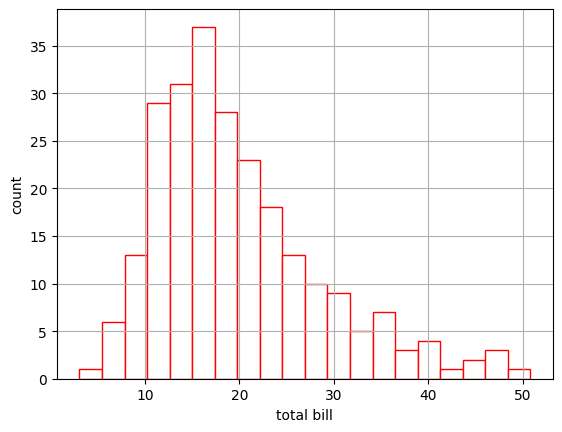

In [107]:
plt.hist(x=tips.total_bill,  # x: 히스토그램을 그리기 위한 연속형 자료(컬럼, 변수).
         bins=20,            # bins: 막대 개수 또는 구간.
         color="white",      # color: 막대 내부를 채우는 색깔.
         edgecolor="red")    # edgecolor: 막대 테두리 색깔.
plt.grid()
plt.xlabel("total bill")
plt.ylabel("count")
plt.show()

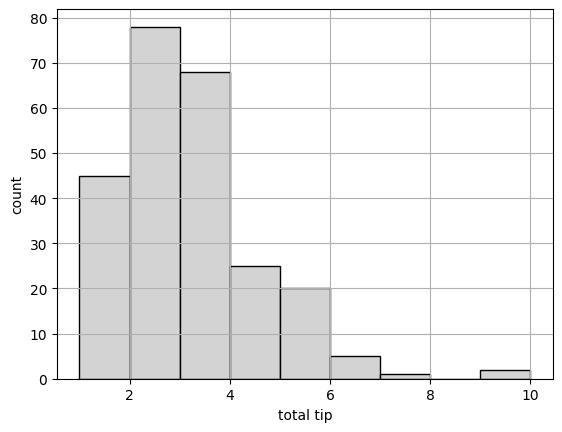

In [108]:
# tip의 히스토그램
plt.hist(x=tips.tip, bins=np.arange(1, 11), color="LightGray", edgecolor="black")
plt.grid()
plt.xlabel("total tip")
plt.ylabel("count")
plt.show()

# Bar graph(막대 그래프)

카테고리(범주) 타입 변수(컬럼)의 빈도수를 막대로 표현한 그래프.

## 세로 막대 그래프(vertical bar graph)

In [109]:
gender_count = tips.sex.value_counts()
gender_count

,count
sex,
Male,157
Female,87


In [110]:
print(type(gender_count))  #> Series

<class 'pandas.core.series.Series'>


In [111]:
gender_count.values  #> 값(빈도수)들을 저장하고 있는 배열

array([157,  87])

In [112]:
gender_count.index  #> 인덱스를 저장하고 있는 배열

CategoricalIndex(['Male', 'Female'], categories=['Male', 'Female'], ordered=False, dtype='category', name='sex')

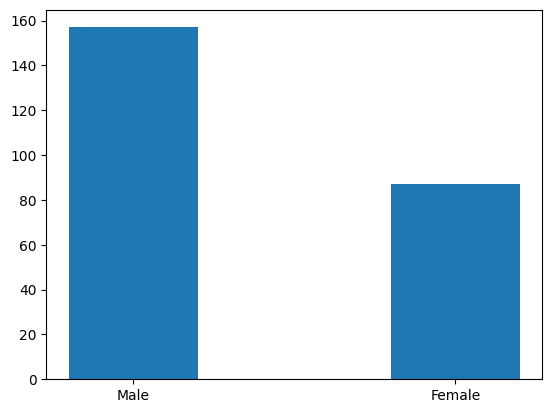

In [113]:
plt.bar(x=gender_count.index, height=gender_count.values, width=0.4)
plt.show()

## 가로 막대 그래프(horizontal bar graph)

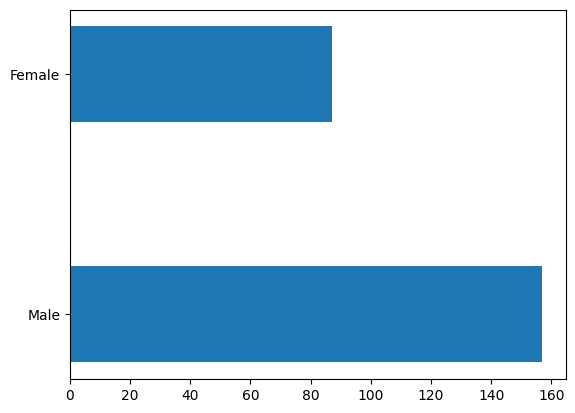

In [114]:
plt.barh(y=gender_count.index, width=gender_count.values, height=0.4)
plt.show()

size의 빈도수를 세로 막대 그래프로 시각화

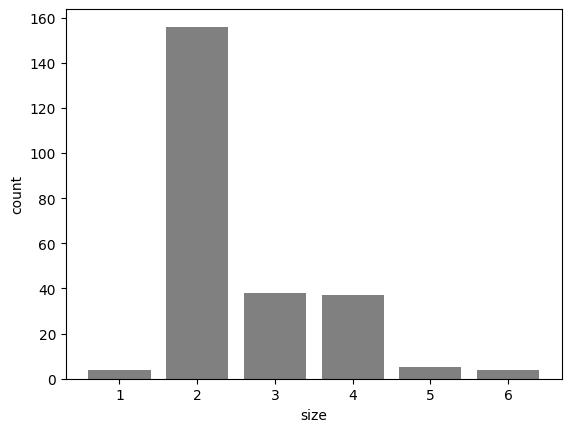

In [116]:
size_tips = tips["size"].value_counts().sort_index()
plt.bar(x=size_tips.index, height=size_tips.values, color="gray")
plt.xlabel("size")
plt.ylabel("count")
plt.show()

요일(day) 빈도수를 가로 막대 그래프로 시각화

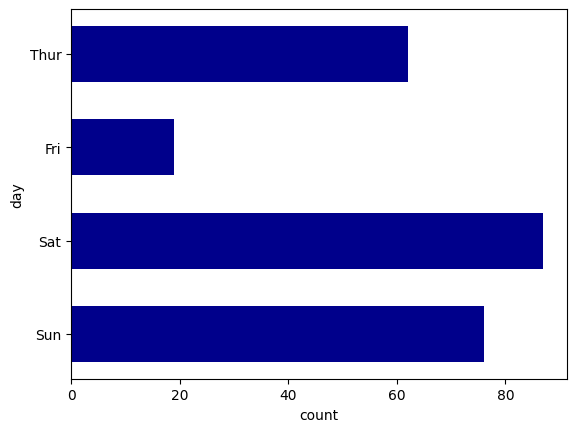

In [117]:
day_tips = tips.day.value_counts().sort_index(ascending=False)
plt.barh(y=day_tips.index, width=day_tips.values, height=0.6, color="darkblue")
plt.xlabel("count")
plt.ylabel("day")
plt.show()

*   4개의 Axes를 2x2 모양(nrows=2, ncols=2)으로 생성.
*   각각의 Axes에 성별 빈도수, 흡연여부 빈도수, 요일 빈도수, 시간 빈도수 (세로) 막대 그래프를 시각화.

In [118]:
# 강사님 답안
gender_count = tips.sex.value_counts()  # 성별 빈도수
smoker_count = tips.smoker.value_counts()  # 흡연여부 빈도수
day_count = tips.day.value_counts()  # 요일 빈도수
time_count = tips.time.value_counts()  # 시간 빈도수

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


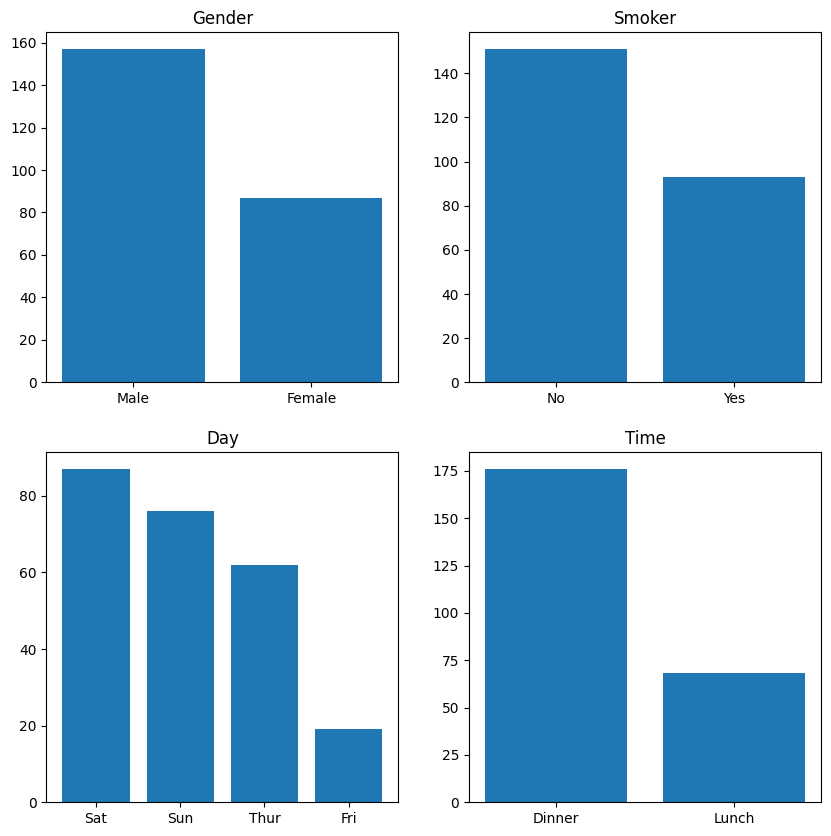

In [119]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
print(axes)  #> 2차원 배열

axes[0, 0].bar(x=gender_count.index, height=gender_count.values)
axes[0, 0].set_title("Gender")

axes[0, 1].bar(x=smoker_count.index, height=smoker_count.values)
axes[0, 1].set_title("Smoker")

axes[1, 0].bar(x=day_count.index, height=day_count.values)
axes[1, 0].set_title("Day")

axes[1, 1].bar(x=time_count.index, height=time_count.values)
axes[1, 1].set_title("Time")

plt.show()

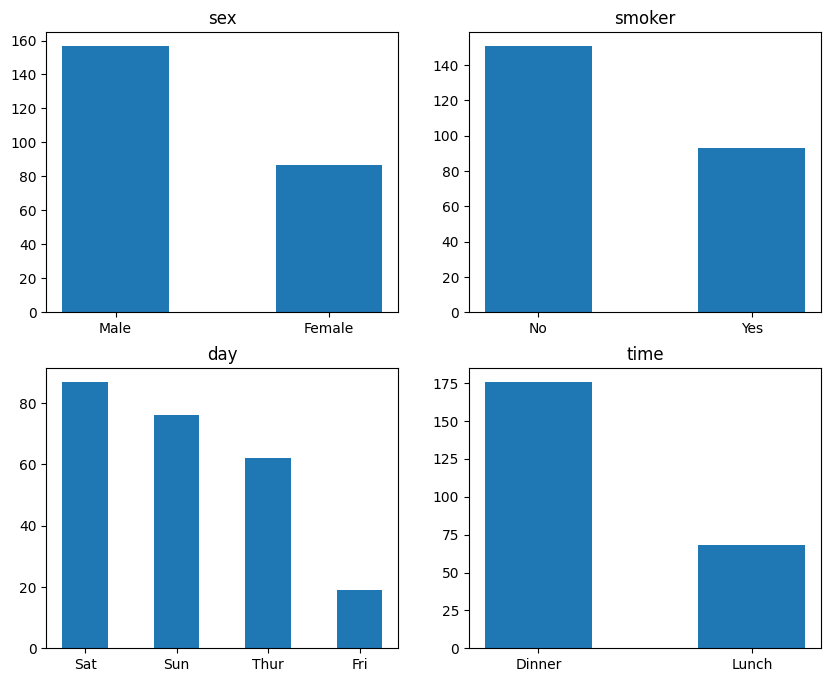

In [120]:
titles = [['sex', 'smoker'], ['day', 'time']]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
for i, row in enumerate(titles):
    for j, t in enumerate(row):
        # print(i, j, t)
        data = tips[t].value_counts()
        axes[i, j].bar(x=data.index, height=data.values, width=0.5)
        axes[i, j].set_title(t)

plt.show()

# Scatter plot(산점도)

*   두 변수 간의 상관관계를 알고 싶을 때 사용.
*   `y ~ x` 관계 시각화.
    *   y: 관심변수, 종속변수
    *   x: 독립변수

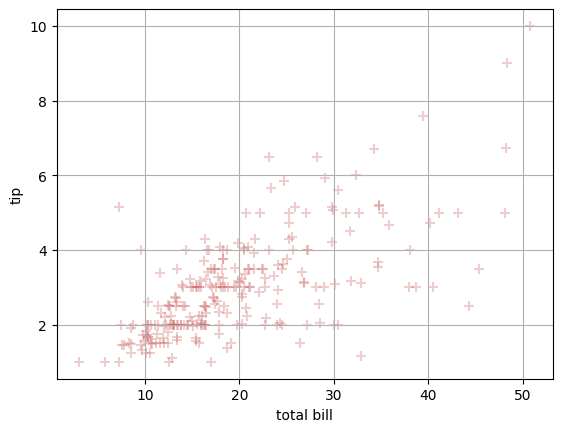

In [127]:
# tip(팁) ~ total_bill(영수증 총액) 관계
plt.scatter(x=tips.total_bill,  # x: x축에 사용할 변수(컬럼)
            y=tips.tip,         # y: y축에 사용할 변수
            alpha=0.3,          # alpha: 불투명도(0=투명, 1:불투명)
            s=50,               # s: size. 마커(점)의 크기.
            c="IndianRed",      # c: color. 마커(점)의 색깔.
            marker = "+")       # marker: 마커(점)의 모양(o, s, ^, v, *, +, ...)
plt.xlabel("total bill")
plt.ylabel("tip")
plt.grid()

plt.show()

*   tip ~ total_bill 상관관계를 산점도로 표현.
*   성별에 따라서 마커의 색깔을 다르게 표현.

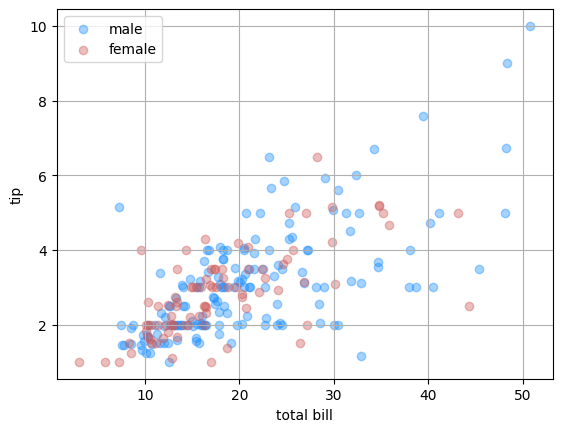

In [139]:
male_df = tips[tips.sex == "Male"]  # 성별이 남성인 데이터프레임
female_df = tips[tips.sex == "Female"]  # 성별이 여성인 데이터프레임

plt.scatter(x=male_df.total_bill, y=male_df.tip,
            alpha=0.4, c="DodgerBlue", label="male")
plt.scatter(x=female_df.total_bill, y=female_df.tip,
            alpha=0.4, c="IndianRed", label="female")

plt.xlabel("total bill")
plt.ylabel("tip")
plt.grid()
plt.legend()  # 범례 표시(scatter 함수의 label 파라미터 값을 표시).

plt.show()

*   tip ~ total_bill 상관관계를 산점도로 표현.
*   성별에 따라서 마커의 색깔을 다르게 표현.
*   흡연여부에 따라서 마커의 모양을 다르게 표현

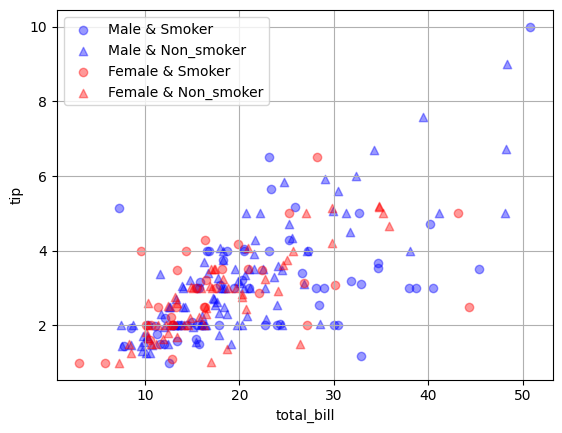

In [148]:
male_smo_df = tips[(tips.sex == "Male") & (tips.smoker == "Yes")]
male_smx_df = tips[(tips.sex == "Male") & (tips.smoker == "No")]
female_smo_df = tips[(tips.sex == "Female") & (tips.smoker == "Yes")]
female_smx_df = tips[(tips.sex == "Female") & (tips.smoker == "No")]

plt.scatter(x=male_smo_df.total_bill, y=male_smo_df.tip, alpha=0.4,
            c="Blue", marker="o", label="Male & Smoker")
plt.scatter(x=male_smx_df.total_bill, y=male_smx_df.tip, alpha=0.4,
            c="Blue", marker="^", label="Male & Non_smoker")
plt.scatter(x=female_smo_df.total_bill, y=female_smo_df.tip, alpha=0.4,
            c="red", marker="o", label = "Female & Smoker")
plt.scatter(x=female_smx_df.total_bill, y=female_smx_df.tip, alpha=0.4,
            c="red", marker="^", label = "Female & Non_smoker")

plt.xlabel("total_bill")
plt.ylabel("tip")
plt.legend()
plt.grid()
plt.show()

In [150]:
# 강사님 답안
tips.sex.cat.categories

Index(['Male', 'Female'], dtype='object')

In [151]:
tips.smoker.cat.categories

Index(['Yes', 'No'], dtype='object')

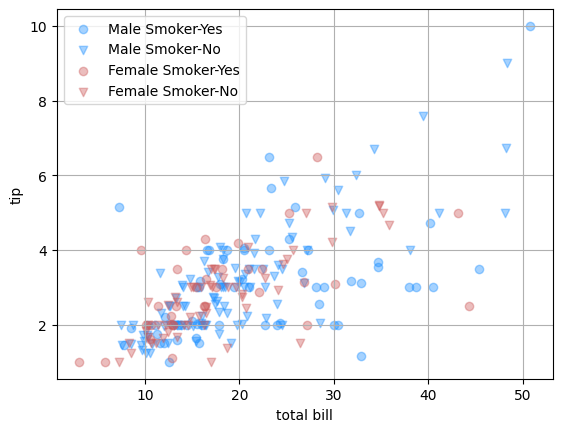

In [159]:
male_smoker = tips[(tips.sex == "Male") & (tips.smoker == "Yes")]  # 남성 흡연자
male_nonsmoker = tips[(tips.sex == "Male") & (tips.smoker == "No")]  # 남성 비흡연자
female_smoker = tips[(tips.sex == "Female") & (tips.smoker == "Yes")]  # 여성 흡연자
female_nonsmoker = tips[(tips.sex == "Female") & (tips.smoker == "No")]  # 여성 비흡연자

plt.scatter(x=male_smoker.total_bill, y=male_smoker.tip,
            alpha=0.4, c="DodgerBlue", marker="o", label="Male Smoker-Yes")
plt.scatter(x=male_nonsmoker.total_bill, y=male_nonsmoker.tip,
            alpha=0.4, c="DodgerBlue", marker="v", label="Male Smoker-No")
plt.scatter(x=female_smoker.total_bill, y=female_smoker.tip,
            alpha=0.4, c="IndianRed", marker="o", label="Female Smoker-Yes")
plt.scatter(x=female_nonsmoker.total_bill, y=female_nonsmoker.tip,
            alpha=0.4, c="IndianRed", marker="v", label="Female Smoker-No")

plt.legend()  # 범례 표시
plt.xlabel("total bill")
plt.ylabel("tip")
plt.grid()

plt.show()

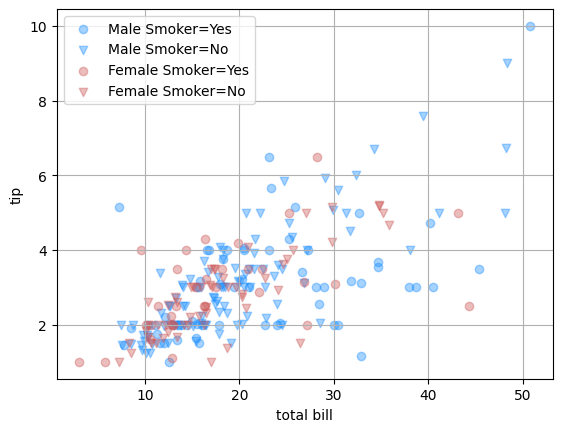

In [164]:
#
gender = tips.sex.cat.categories  # ["Male", "Female"]
smoker = tips.smoker.cat.categories  # ["Yes", "No"]
colors = ["DodgerBlue", "IndianRed"]
markers = ["o", "v"]

for g, c in zip(gender, colors):
    for s,m in zip(smoker, markers):
        df = tips[(tips.sex == g) & (tips.smoker == s)]
        plt.scatter(x=df.total_bill, y=df.tip, alpha=0.4,
                    c=c, marker=m, label=f"{g} Smoker={s}")


plt.legend()
plt.xlabel("total bill")
plt.ylabel("tip")
plt.grid()
plt.show()

*   1개의 Figure에 상/하 2개의 Axes를 생성.
*   위쪽 Axes에는 total_bill의 히스토그램을 작성.
*   아래쪽 Axes에는 tip ~ total_bill의 산점도를 작성.

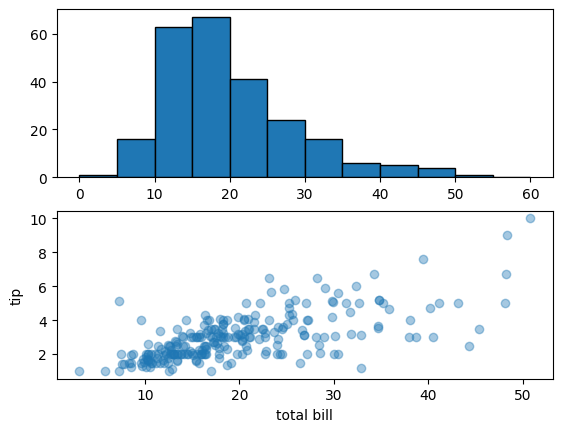

In [183]:
fig, ax_fg = plt.subplots(nrows=2, ncols=1)

ax_fg[0].hist(x=tips.total_bill, edgecolor="black", bins=np.arange(0, 61, 5))
ax_fg[1].scatter(x=tips.total_bill, y=tips.tip, alpha=0.4)

ax_fg[1].set_xlabel("total bill")
ax_fg[1].set_ylabel("tip")

plt.show()

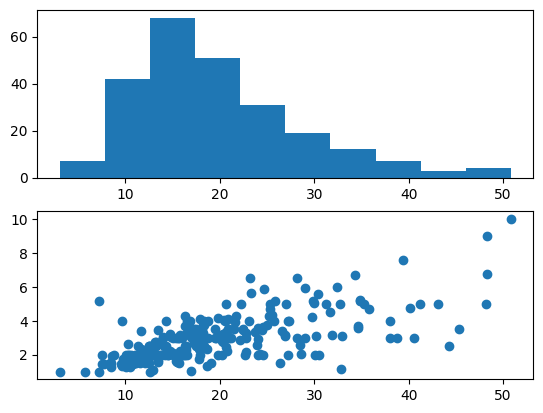

In [179]:
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax1.hist(x=tips.total_bill)
ax2.scatter(x=tips.total_bill, y=tips.tip)

plt.show()

# Line Plot(선 그래프)

주로 시계열 데이터(주식, 환율, 부동산, 지지도, 미세먼지 농도, ...)를 시각화.

In [184]:
# 선 그래프를 그리기 위한 가상의 데이터
np.random.seed(1)  # 실행할 때마다 같은 난수들이 만들어지도록 하기 위해서.
df = pd.DataFrame(data={
    "day": np.arange(1, 11),
    "price": np.random.rand(10)
})
df

,day,price
0,1,0.417022
1,2,0.720324
2,3,0.000114
3,4,0.302333
4,5,0.146756
5,6,0.092339
6,7,0.186260
7,8,0.345561
8,9,0.396767
9,10,0.538817


`plt.plt([x], y [fmt])`

*   x: x좌표로 사용할 변수. 생략 가능. 생략했을 때 인덱스가 x좌표로 사용됨.
*   y: y좌표로 사용할 변수. 필수.
*   fmt: 포맷 문자열. color(선과 마커의 색깔), marker(마커 모양), linestyle(선 스타일) 정보를 문자열로 표현. 생략 가능. 생략했을 때는 마커 없이 직선으로 표시.
    *   color: r(red), g(green), b(blue), k(black)
    *   marker: o, s, ^, v, *, +, ...
    *   linestyle: -(직선, solid line), --(dashed line), :(점섬, dotted line), ...
    *   (예) 'ro-', 'bo:'

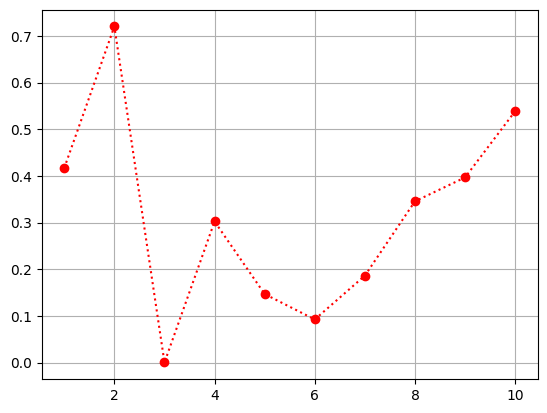

In [202]:
# plt.plot([x], ym [fmt])
plt.plot(df.day, df.price, "ro:")

plt.grid()
plt.show()

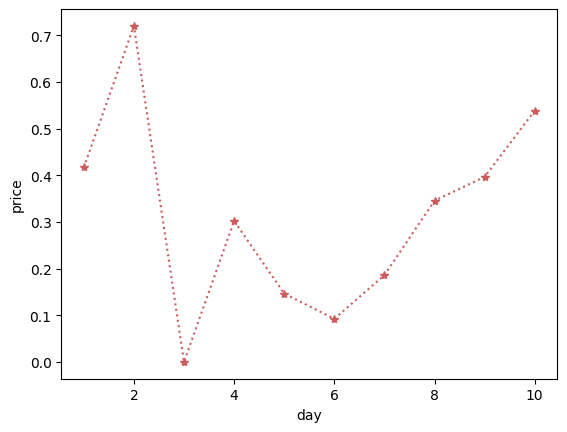

In [213]:
plt.plot(df.day, df.price, color="IndianRed", marker="*", linestyle="dotted")
plt.xlabel("day")
plt.ylabel("price")
plt.show()

아래의 데이터프레임에서 samsung, hynix, nvidia 데이터를 선 그래프로 표현.

*   1개의 Axes에 선 그래프 3개를 표시.
*   각각의 데이터는 다른 색깔, 마커, 선 스타일로 표현.
*   범례 표시.

In [214]:
np.random.seed(1)
df = pd.DataFrame(data={
    "samsung": np.random.rand(10),
    "hynix": np.random.rand(10),
    "nvidia": np.random.rand(10)
})
df

,samsung,hynix,nvidia
0,0.417022,0.419195,0.800745
1,0.720324,0.685220,0.968262
2,0.000114,0.204452,0.313424
3,0.302333,0.878117,0.692323
4,0.146756,0.027388,0.876389
5,0.092339,0.670468,0.894607
6,0.186260,0.417305,0.085044
7,0.345561,0.558690,0.039055
8,0.396767,0.140387,0.169830
9,0.538817,0.198101,0.878143


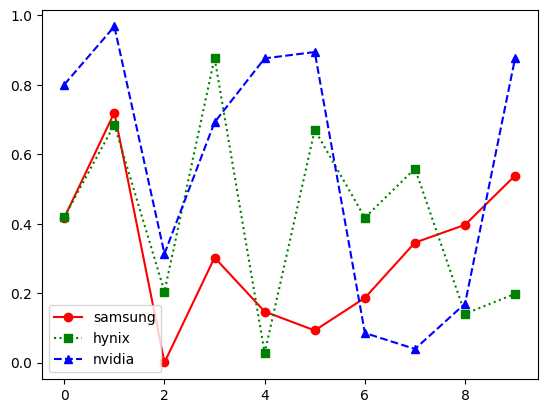

In [228]:
fig, ax_1 = plt.subplots(nrows=1, ncols=1)

ax_1.plot(df.samsung, "ro-", label="samsung")
ax_1.plot(df.hynix, "gs:", label="hynix")
ax_1.plot(df.nvidia, "b^--", label="nvidia")

plt.legend()
plt.show()

# 연습문제: iris 데이터셋 시각화

*   seaborn 패키지의 iris 예제 데이터셋을 로드.
*   DataFrame을 확인
*   가능한 시각화 표현 방법(그래프 종류) 선택.

In [231]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


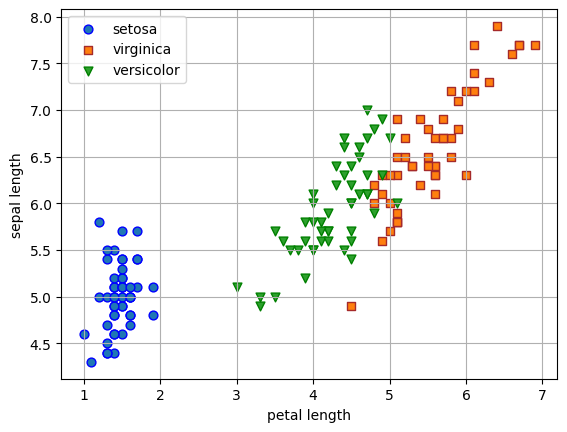

In [255]:
setosa_iris = iris[iris.species == "setosa"]
virginica_iris = iris[iris.species == "virginica"]
versicolor_iris = iris[iris.species == "versicolor"]

plt.scatter(x=setosa_iris.petal_length, y=setosa_iris.sepal_length,
            s=40, marker="o", edgecolor="blue", label="setosa")
plt.scatter(x=virginica_iris.petal_length, y=virginica_iris.sepal_length,
            s=40, marker="s", edgecolor="brown", label="virginica")
plt.scatter(x=versicolor_iris.petal_length, y=versicolor_iris.sepal_length,
            s=40, marker="v", edgecolor="green", label="versicolor")

plt.xlabel("petal length")
plt.ylabel("sepal length")
plt.legend()
plt.grid()
plt.show()

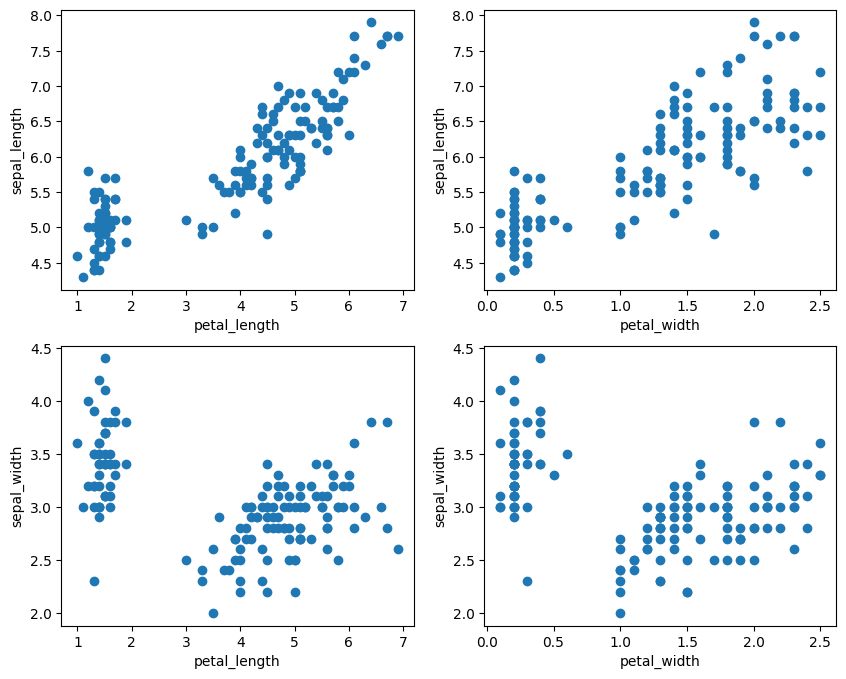

In [295]:
# 1. 주어진 두 개의 리스트
parts = ['sepal', 'petal']
measures = ['length', 'width']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 2. 이중 반복문
for i, row_m in enumerate(measures):
    for j, col_m in enumerate(measures):

        # 3. 문자열 조립 (f-string)
        # y축: sepal + _ + (length or width)
        # x축: petal + _ + (length or width)
        y_col = f"{parts[0]}_{row_m}"
        x_col = f"{parts[1]}_{col_m}"

        axes[i, j].scatter(x=iris[x_col], y=iris[y_col])
        axes[i, j].set_xlabel(f"{parts[1]}_{col_m}")
        axes[i, j].set_ylabel(f"{parts[0]}_{row_m}")

In [266]:
# 강사님 답안
species_count = iris.species.value_counts()
species_count

,count
species,
setosa,50
versicolor,50
virginica,50


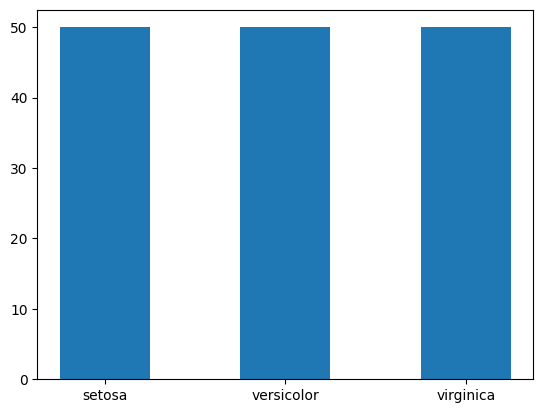

In [268]:
# 막대 그래프(bar plot) - 카테고리 타입 변수의 빈도수
plt.bar(x=species_count.index, height=species_count.values, width = 0.5)
plt.show()

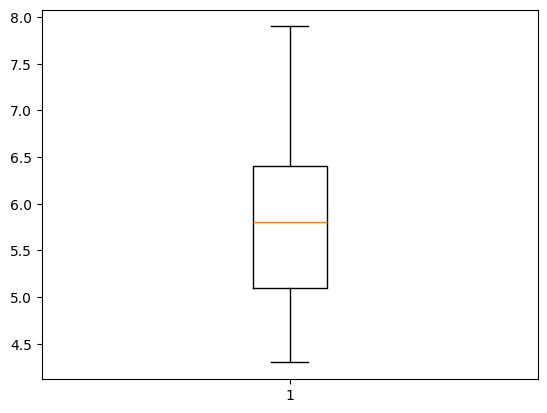

In [269]:
# box plot - 연속형 자료의 분포(최솟값, 25%, 50%, 75%, 최댓값)
plt.boxplot(x=iris.sepal_length)
plt.show()

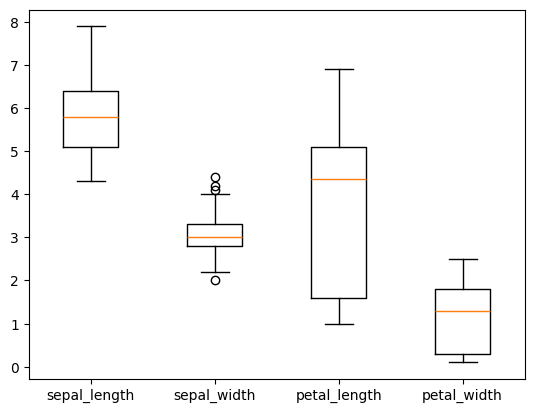

In [272]:
plt.boxplot(x=[iris.sepal_length, iris.sepal_width, iris.petal_length, iris.petal_width], tick_labels= ["sepal_length", "sepal_width", "petal_length", "petal_width"])

plt.show()

In [278]:
iris.columns[:-1]  # 배열 slicing

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

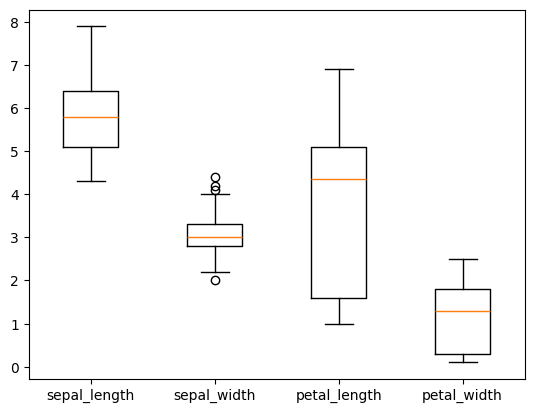

In [274]:
plt.boxplot(x=iris[iris.columns[:-1]], tick_labels=iris.columns[:-1])
plt.show()

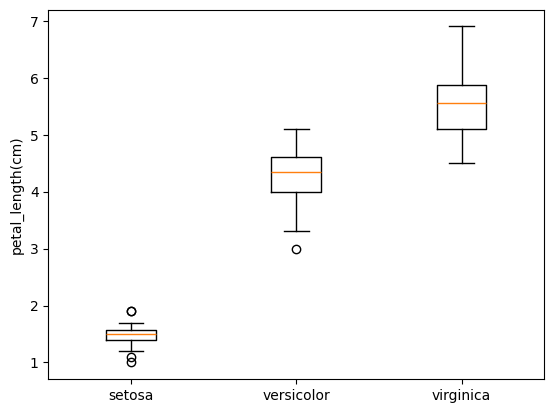

In [301]:
# 붓꽃의 품종별로 petal_length의 box plot
data = []  # 품종별 petal_length를 저장하기 위한 변수
for s in iris.species.unique():
    sl = iris[iris.species == s].petal_length
    data.append(sl)

plt.boxplot(x=data, tick_labels=iris.species.unique())
plt.ylabel("petal_length(cm)")
plt.show()

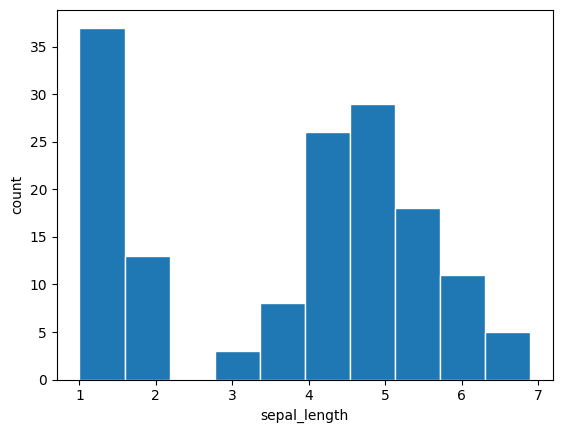

In [300]:
# sepal_length의 히스토그램
plt.hist(x=iris.petal_length, edgecolor="white")
plt.xlabel("sepal_length")
plt.ylabel("count")
plt.show()

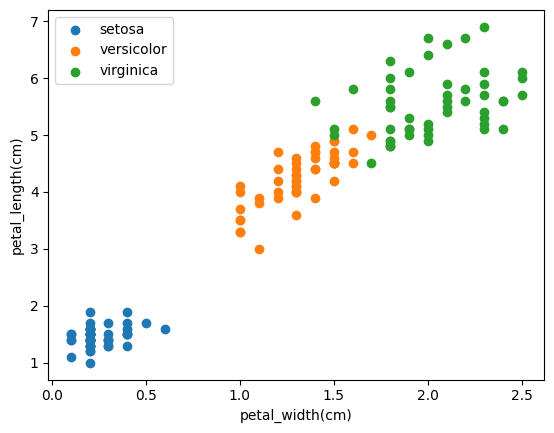

In [307]:
# petal_length ~ petal_width 산점도, 품종별로 마커 색깔을 다르게 표시.
species = iris.species.unique()
for s in species:
    df = iris[iris.species == s]
    plt.scatter(df.petal_width, df.petal_length, label=s)

plt.legend()
plt.xlabel("petal_width(cm)")
plt.ylabel("petal_length(cm)")
plt.show()